# DSPy as a Bridge Between Agents
### Does a dynamic instruction layer improve agent-to-agent email extraction?

**Setup:** One email → Agent 1 creates an empty JSON schema → Agent 2 fills it.

**Question:** Does adding a DSPy-generated instruction layer between Agent 1 and Agent 2
give Agent 2 better field coverage than a static system prompt alone?

## Setup

In [ ]:
import json
from openai import AsyncAzureOpenAI
from agents import Agent, Runner, ModelSettings
from agents.models.openai_chatcompletions import OpenAIChatCompletionsModel

AZURE_API_KEY     = ""
AZURE_ENDPOINT    = ""
AZURE_API_VERSION = ""
AZURE_DEPLOYMENT  = ""

azure_client = AsyncAzureOpenAI(
    api_key=AZURE_API_KEY,
    api_version=AZURE_API_VERSION,
    azure_endpoint=AZURE_ENDPOINT,
)

In [2]:
with open("..\\..\\playground\\japanese_email_test.json", encoding="utf-8") as f:
    emails = json.load(f)

email_text = emails["email_01"]
print(f"Email loaded ({len(email_text)} chars). Preview:")
print(email_text[:300], "...")

Email loaded (1404 chars). Preview:
差出人: 山本健太 <yamamoto.kenta@suzuki-sekkei.co.jp>
宛先: bids@globalparts.com
日付: 2026年5月26日（月曜日）午前10時32分
件名: 【緊急】6軸アーク溶接ロボット調達依頼

グローバルパーツ株式会社
購買ご担当者様

お世話になっております。
鈴木設計株式会社　調達部の山本健太と申します。

弊社では名古屋第2工場の溶接ラインを増設するにあたり、6軸アーク溶接ロボットの調達を計画しております。つきましては、下記の要件にて御見積りをお願い申し上げます。

━━━━━━━━━━━━━━━━━━━━
【品目】
━━━━━━━ ...


## Step 1 — Agent 1: Schema Extraction

The first agent reads the email and produces an **empty JSON schema** —
keys inferred from the email content, all values blank.
Agent 2 will fill those values.

In [3]:
email_reader_agent = Agent(
    name="Email Reader",
    instructions=(
        "Read the email, understand its intent, and produce a JSON skeleton: "
        "correct keys derived from the email, all values empty strings or empty arrays. "
        "Output only valid JSON - no commentary."
    ),
    model=OpenAIChatCompletionsModel(model=AZURE_DEPLOYMENT, openai_client=azure_client),
    model_settings=ModelSettings(temperature=0),
)

reader_result = await Runner.run(email_reader_agent, email_text)
empty_schema  = reader_result.final_output

print("=== Empty JSON Schema from Agent 1 ===")
print(empty_schema)

=== Empty JSON Schema from Agent 1 ===
```json
{
  "sender": "",
  "recipient": "",
  "date": "",
  "subject": "",
  "company": "",
  "contact_person": {
    "name": "",
    "position": "",
    "email": "",
    "phone": "",
    "address": ""
  },
  "request_details": {
    "item": {
      "name": "",
      "model": []
    },
    "quantity": "",
    "budget": {
      "amount": "",
      "currency": "",
      "tax_included": "",
      "installation_included": "",
      "maintenance_contract": {
        "duration": "",
        "separate_estimate": ""
      }
    },
    "delivery_schedule": [],
    "technical_specifications": {
      "protection_rating": "",
      "repeatability": "",
      "payload_capacity": "",
      "reach": "",
      "controller": ""
    },
    "compliance": [],
    "bidding_conditions": {
      "submission_deadline": "",
      "warranty_details": "",
      "inspection_schedule": {
        "factory_acceptance_test": "",
        "site_acceptance_test": ""
      },
    

OPENAI_API_KEY is not set, skipping trace export


## Baseline — Agent 2 Without DSPy

Agent 2 gets the email and the empty schema with a **static, generic system prompt**.
It has no tailored guidance — just a broad instruction to fill the JSON.

In [4]:
auditor_agent = Agent(
    name="Auditor Writer Agent",
    instructions=(
        "You are an auditor agent. Fill the JSON schema using values from the email. "
        "Return only clean, valid JSON - no markdown, no commentary."
    ),
    model=OpenAIChatCompletionsModel(model=AZURE_DEPLOYMENT, openai_client=azure_client),
    model_settings=ModelSettings(temperature=0),
)

no_dspy_input = "Email:\n" + email_text + "\n\nEmpty JSON Schema:\n" + empty_schema
result_without_dspy = await Runner.run(auditor_agent, no_dspy_input)

print("=== Agent 2 Output (No DSPy) ===")
print(result_without_dspy.final_output)

OPENAI_API_KEY is not set, skipping trace export


=== Agent 2 Output (No DSPy) ===
```json
{
  "sender": "山本健太 <yamamoto.kenta@suzuki-sekkei.co.jp>",
  "recipient": "bids@globalparts.com",
  "date": "2026年5月26日（月曜日）午前10時32分",
  "subject": "【緊急】6軸アーク溶接ロボット調達依頼",
  "company": "鈴木設計株式会社",
  "contact_person": {
    "name": "山本健太",
    "position": "調達部長",
    "email": "yamamoto.kenta@suzuki-sekkei.co.jp",
    "phone": "052-432-8800（内線312）",
    "address": "〒460-0008 愛知県名古屋市中区栄3丁目18番1号"
  },
  "request_details": {
    "item": {
      "name": "6軸アーク溶接ロボット",
      "model": [
        "FANUCロボット M-10iA/12",
        "安川電機 Motoman MA1440",
        "同等品可"
      ]
    },
    "quantity": 18,
    "budget": {
      "amount": 220000000,
      "currency": "JPY",
      "tax_included": false,
      "installation_included": true,
      "maintenance_contract": {
        "duration": "3年",
        "separate_estimate": true
      }
    },
    "delivery_schedule": [
      {
        "quantity": 6,
        "date": "2026年9月15日"
      },
      {
        "quantity":

OPENAI_API_KEY is not set, skipping trace export


## The DSPy Bridge — Self-Questioning Schema Enricher

DSPy does **two things** a static prompt cannot:

1. **Questions itself** — *"What information is in this email that Agent 1 never captured?"*
2. **Enriches the schema** — adds missing fields and splits vague ones, then gives Agent 2 per-field extraction hints.

Agent 2 fills the **enriched schema**, not the original one. The difference in field count is the value DSPy adds.

In [5]:
import dspy

dspy.configure(
    lm=dspy.LM(
        model=f"azure/{AZURE_DEPLOYMENT}",
        api_key=AZURE_API_KEY,
        api_base=AZURE_ENDPOINT,
        api_version=AZURE_API_VERSION,
        temperature=0,
    )
)

class SelfQAEnricher(dspy.Signature):
    """
    Audit the schema against the email by asking yourself:
      - What information exists in the email that has NO field in the schema?
      - Which fields are vague and should be broken into clearer sub-fields?
    Then produce:
      1. enriched_schema: original fields PLUS every newly discovered field,
         ALL values must stay empty strings or empty arrays.
      2. field_hints: one concise extraction hint per field telling Agent 2
         exactly where in the email to find the value.
    """
    email           = dspy.InputField(desc="Raw email text (may be in any language)")
    initial_schema  = dspy.InputField(desc="Initial empty JSON schema from Agent 1")
    enriched_schema = dspy.OutputField(
        desc="Enriched empty JSON — all original fields PLUS newly discovered ones. Every value must be an empty string or empty array."
    )
    field_hints     = dspy.OutputField(
        desc="Concise per-field hint for Agent 2: e.g. 'sender -> From line', 'amc_duration -> found in budget paragraph'"
    )

class SelfQAModule(dspy.Module):
    def __init__(self):
        self.enrich = dspy.ChainOfThought(SelfQAEnricher)

    def forward(self, email, initial_schema):
        out = self.enrich(email=email, initial_schema=initial_schema)
        return out.enriched_schema, out.field_hints

enricher = SelfQAModule()
enriched_schema, field_hints = enricher(email=email_text, initial_schema=empty_schema)

# Agent 2 gets: hints + email + enriched schema (not the original)
auditor_input = f"""Field Extraction Hints:
{field_hints}

Email:
{email_text}

JSON Schema to fill (enriched by DSPy):
{enriched_schema}"""

print("=== DSPy Enriched Schema ===")
print(enriched_schema)
print("\n=== DSPy Field Hints ===")
print(field_hints)

11:45:42 - LiteLLM:WARNING: get_model_cost_map.py:271 - LiteLLM: Failed to fetch remote model cost map from https://raw.githubusercontent.com/BerriAI/litellm/main/model_prices_and_context_window.json: [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1081). Falling back to local backup.


=== DSPy Enriched Schema ===
```json
{
  "sender": "",
  "recipient": "",
  "date": "",
  "subject": "",
  "company": "",
  "contact_person": {
    "name": "",
    "position": "",
    "email": "",
    "phone": {
      "number": "",
      "extension": ""
    },
    "address": {
      "street": "",
      "city": "",
      "postal_code": "",
      "country": ""
    }
  },
  "request_details": {
    "item": {
      "name": "",
      "model": []
    },
    "quantity": "",
    "budget": {
      "amount": "",
      "currency": "",
      "tax_included": "",
      "installation_included": "",
      "maintenance_contract": {
        "duration": "",
        "separate_estimate": ""
      }
    },
    "delivery_schedule": [
      {
        "quantity": "",
        "date": ""
      }
    ],
    "final_operational_date": "",
    "technical_specifications": {
      "protection_rating": "",
      "repeatability": "",
      "payload_capacity": "",
      "reach": "",
      "controller": ""
    },
    "com

## With DSPy — Same Agent 2, Better Instructions

The **same agent** now receives DSPy's tailored guidance instead of the generic prompt.
No model change, no fine-tuning — only the instruction layer changed.

In [6]:
result_with_dspy = await Runner.run(auditor_agent, auditor_input)

print("=== Agent 2 Output (With DSPy) ===")
print(result_with_dspy.final_output)

OPENAI_API_KEY is not set, skipping trace export


=== Agent 2 Output (With DSPy) ===
```json
{
  "sender": "山本健太 <yamamoto.kenta@suzuki-sekkei.co.jp>",
  "recipient": "bids@globalparts.com",
  "date": "2026年5月26日（月曜日）午前10時32分",
  "subject": "【緊急】6軸アーク溶接ロボット調達依頼",
  "company": "鈴木設計株式会社",
  "contact_person": {
    "name": "山本健太",
    "position": "調達部長",
    "email": "yamamoto.kenta@suzuki-sekkei.co.jp",
    "phone": {
      "number": "052-432-8800",
      "extension": "312"
    },
    "address": {
      "street": "栄3丁目18番1号",
      "city": "名古屋市中区",
      "postal_code": "460-0008",
      "country": "Japan"
    }
  },
  "request_details": {
    "item": {
      "name": "6軸アーク溶接ロボット",
      "model": ["FANUCロボット M-10iA/12", "安川電機 Motoman MA1440"]
    },
    "quantity": "18",
    "budget": {
      "amount": "220000000",
      "currency": "JPY",
      "tax_included": "false",
      "installation_included": "true",
      "maintenance_contract": {
        "duration": "3年",
        "separate_estimate": "true"
      }
    },
    "delivery_schedu

## Results — Coverage Comparison

OPENAI_API_KEY is not set, skipping trace export


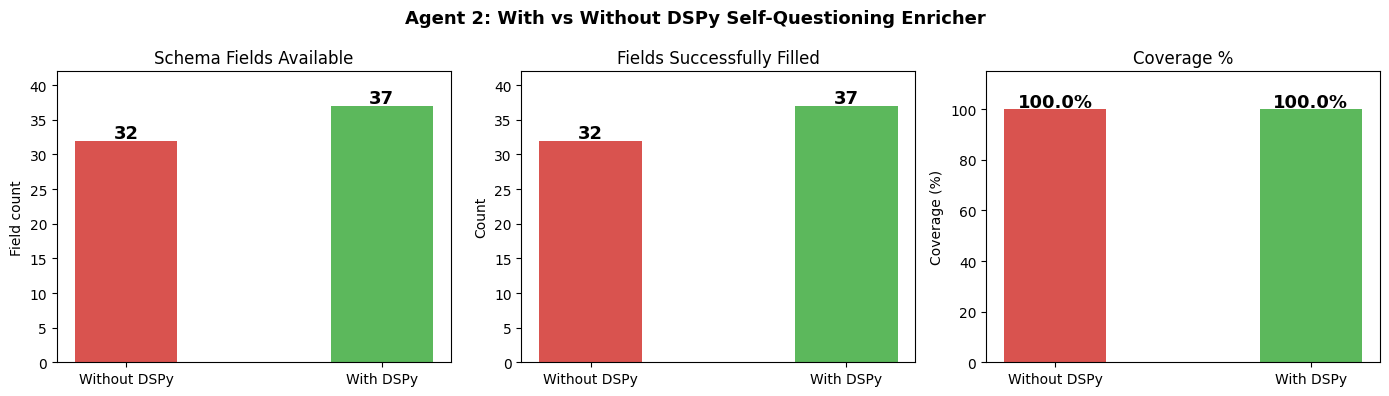


Metric                                Without DSPy     With DSPy
-----------------------------------------------------------------
Schema fields (input to Agent 2)                32            37
Fields filled                                   32            37
Coverage                                    100.0%        100.0%
New fields added by DSPy                         —             7
New fields filled by Agent 2                     —             7

Fields DSPy added to schema (7 total):
  + contact_person.address.city  [filled]
  + contact_person.address.country  [filled]
  + contact_person.address.postal_code  [filled]
  + contact_person.address.street  [filled]
  + contact_person.phone.extension  [filled]
  + contact_person.phone.number  [filled]
  + request_details.final_operational_date  [filled]


In [7]:
import re, json
import matplotlib.pyplot as plt

def extract_json(text):
    match = re.search(r"\{.*\}", text, re.DOTALL)
    try:
        return json.loads(match.group()) if match else {}
    except Exception:
        return {}

def flat_fields(obj, prefix=""):
    """Return {dotted.key: is_filled} for every leaf."""
    out = {}
    if isinstance(obj, dict):
        for k, v in obj.items():
            out.update(flat_fields(v, f"{prefix}.{k}" if prefix else k))
    elif isinstance(obj, list):
        out[prefix] = bool(obj)
    else:
        out[prefix] = obj is not None and str(obj).strip() not in ("", "null", "None")
    return out

# Parse all three: original schema, without-DSPy result, with-DSPy result
j_original = extract_json(empty_schema)
j_no       = extract_json(result_without_dspy.final_output)
j_yes      = extract_json(result_with_dspy.final_output)
j_enriched = extract_json(enriched_schema)

flat_orig    = flat_fields(j_original)
flat_no      = flat_fields(j_no)
flat_yes     = flat_fields(j_yes)
flat_enriched = flat_fields(j_enriched)

orig_keys     = set(flat_orig.keys())
enriched_keys = set(flat_enriched.keys())
new_keys      = enriched_keys - orig_keys        # fields DSPy added

filled_no      = sum(flat_no.values())
filled_yes     = sum(flat_yes.values())
total_no       = len(flat_no)
total_yes      = len(flat_yes)
pct_no         = filled_no  / total_no  * 100 if total_no  else 0
pct_yes        = filled_yes / total_yes * 100 if total_yes else 0

# New fields that actually got filled by Agent 2
new_filled = [k for k in new_keys if flat_yes.get(k)]

# ── Bar chart ─────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Agent 2: With vs Without DSPy Self-Questioning Enricher", fontsize=13, fontweight="bold")

labels = ["Without DSPy", "With DSPy"]
red, green = "#d9534f", "#5cb85c"

# Left: total fields in schema
axes[0].bar(labels, [total_no, total_yes], color=[red, green], width=0.4)
axes[0].set_title("Schema Fields Available")
axes[0].set_ylabel("Field count")
axes[0].set_ylim(0, max(total_no, total_yes) + 5)
for i, v in enumerate([total_no, total_yes]):
    axes[0].text(i, v + 0.4, str(v), ha="center", fontweight="bold", fontsize=13)

# Centre: fields filled
axes[1].bar(labels, [filled_no, filled_yes], color=[red, green], width=0.4)
axes[1].set_title("Fields Successfully Filled")
axes[1].set_ylabel("Count")
axes[1].set_ylim(0, max(total_no, total_yes) + 5)
for i, v in enumerate([filled_no, filled_yes]):
    axes[1].text(i, v + 0.4, str(v), ha="center", fontweight="bold", fontsize=13)

# Right: coverage %
axes[2].bar(labels, [pct_no, pct_yes], color=[red, green], width=0.4)
axes[2].set_title("Coverage %")
axes[2].set_ylabel("Coverage (%)")
axes[2].set_ylim(0, 115)
for i, v in enumerate([pct_no, pct_yes]):
    axes[2].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold", fontsize=13)

plt.tight_layout()
plt.savefig("dspy_vs_no_dspy.png", dpi=150, bbox_inches="tight")
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────────
print(f"\n{'Metric':<35} {'Without DSPy':>14}  {'With DSPy':>12}")
print("-" * 65)
print(f"{'Schema fields (input to Agent 2)':<35} {total_no:>14}  {total_yes:>12}")
print(f"{'Fields filled':<35} {filled_no:>14}  {filled_yes:>12}")
print(f"{'Coverage':<35} {pct_no:>13.1f}%  {pct_yes:>11.1f}%")
print(f"{'New fields added by DSPy':<35} {'—':>14}  {len(new_keys):>12}")
print(f"{'New fields filled by Agent 2':<35} {'—':>14}  {len(new_filled):>12}")

if new_keys:
    print(f"\nFields DSPy added to schema ({len(new_keys)} total):")
    for k in sorted(new_keys):
        status = "filled" if flat_yes.get(k) else "empty (not in email)"
        print(f"  {'+ ' if flat_yes.get(k) else '  '}{k}  [{status}]")

## Key Takeaway

| | Without DSPy | With DSPy |
|---|---|---|
| Instruction source | Static system prompt | Dynamically generated per email |
| Model changed? | No | No |
| Fine-tuning needed? | No | No |
| Extra cost | — | One additional LLM call |

**DSPy acts as a reasoning layer between agents** — it reads the actual email and schema,
then writes the most relevant instructions for Agent 2 to follow.

Higher field coverage from the same model, with no prompt engineering effort
required per email type or language.